# Valencia sidewalk routing — accessibility model demo

Exercises the accessibility-aware routing pipeline:

1. **Citywide maps** — where Valencia's sidewalks are wide enough, and how the slope penalty inflates `alt_distance`.
2. **Per-edge distributions** — slope and cost-multiplier histograms with the CTE / DB-SUA thresholds marked.
3. **Route comparison** — several origin/destination pairs routed both by raw `distance` and by the accessibility-weighted `alt_distance`.

The cost model is Option 2 from `docs/alt_distance_proposal.pdf`:

$$\text{alt\_distance} \;=\; \text{distance}\cdot \exp\!\bigl(k_{\uparrow}\,\max(s,0) + k_{\downarrow}\,\max(-s,0)\bigr)\,\big/\,10^{A}$$

with CTE-anchored defaults $k_{\uparrow}=38,\ k_{\downarrow}=23$ and $A\in\{0,1\}$ the width gate ($w \ge 1{,}50\,\text{m}$).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from shapely.geometry import Point

from src.network import Network

DB_PATH = "data/network.duckdb"
network = Network(DB_PATH)

# Materialise every edge geometry once so every plot below can use the
# same backdrop without re-decoding WKB.
edges_gdf = network.edges.copy()
edges_gdf["geometry"] = edges_gdf.apply(network.get_linestring, axis=1)
edges_gdf = gpd.GeoDataFrame(edges_gdf, geometry="geometry", crs=network.crs)

# Derived columns used throughout the notebook.
edges_gdf["ratio"]     = edges_gdf["alt_distance"] / edges_gdf["distance"]
edges_gdf["abs_slope"] = edges_gdf["slope"].abs()

print(f"Loaded {len(network.nodes):,} nodes / {len(edges_gdf):,} edges in {network.crs}")

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 79013
Setting CH edge vector of size 240458
Range graph removed 242722 edges of 480916
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Loaded 79,013 nodes / 240,458 edges in EPSG:25830


## Network overview

Summary statistics for the columns that drive routing.

In [2]:
edges_gdf[["distance", "alt_distance", "ratio", "width", "slope", "accesibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
distance,240458.0,47.835829,83.526195,0.097065,8.937157,23.186968,57.974363,3.402006e+03
alt_distance,240458.0,466.431079,22416.049740,0.009707,1.786976,6.660312,19.747867,5.756902e+06
ratio,240458.0,95.444044,5001.824120,0.100000,0.100000,0.100000,1.000000,8.932172e+05
width,240458.0,3.049277,1.898246,1.000000,1.532809,2.401087,3.878934,8.000000e+00
slope,240458.0,0.000000,0.040202,-2.725989,0.000000,0.000000,0.000000,2.725989e+00
accesibility,240458.0,0.770455,0.420541,0.000000,1.000000,1.000000,1.000000,1.000000e+00


## Citywide accessibility (width gate)

Binary `accesibility` column: 1 when `width ≥ 1.50 m` (the TMA/851 *estrechamiento puntual* limit), 0 otherwise.

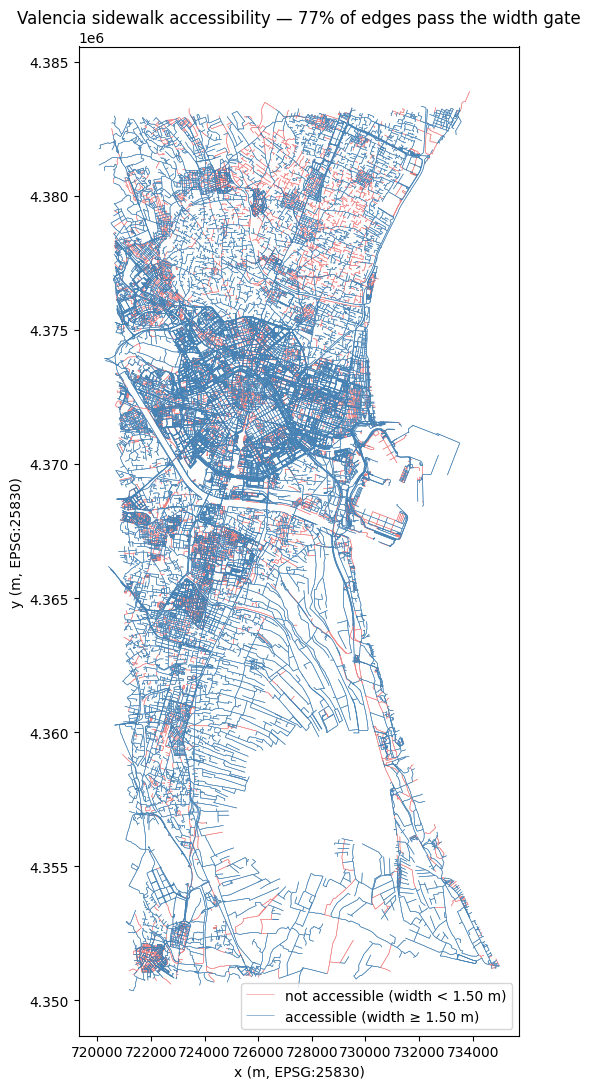

In [3]:
fig, ax = plt.subplots(figsize=(11, 11))
edges_gdf[edges_gdf["accesibility"] == 0].plot(
    ax=ax, color="lightcoral", linewidth=0.4, label="not accessible (width < 1.50 m)",
)
edges_gdf[edges_gdf["accesibility"] == 1].plot(
    ax=ax, color="steelblue", linewidth=0.4, label="accessible (width \u2265 1.50 m)",
)
share = (edges_gdf["accesibility"] == 1).mean() * 100
ax.set_aspect("equal")
ax.set_title(f"Valencia sidewalk accessibility \u2014 {share:.0f}% of edges pass the width gate")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
ax.legend(loc="lower right")
plt.tight_layout()

## Citywide cost multiplier

`alt_distance / distance` per edge — the inflation factor the accessibility router applies. Below 1 means *preferred* (wide and flat); above 1 means *penalised* (narrow or steep). Plotted on a log colour scale because the ratio spans roughly 0.1 (flat and wide) to ~50+ (steep and narrow).

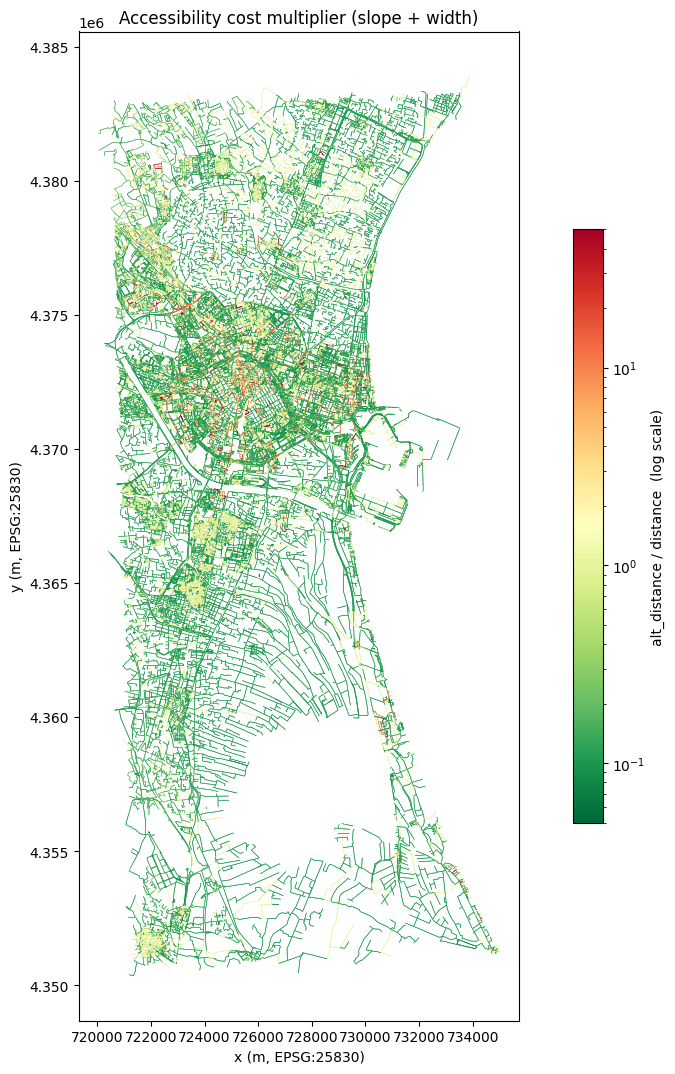

In [4]:
fig, ax = plt.subplots(figsize=(11, 11))
r = edges_gdf["ratio"].clip(lower=0.05, upper=50)
edges_gdf.assign(_r=r).plot(
    ax=ax,
    column="_r",
    cmap="RdYlGn_r",
    linewidth=0.4,
    norm=LogNorm(vmin=0.05, vmax=50),
    legend=True,
    legend_kwds={"label": "alt_distance / distance  (log scale)", "shrink": 0.6},
)
ax.set_aspect("equal")
ax.set_title("Accessibility cost multiplier (slope + width)")
ax.set_xlabel("x (m, EPSG:25830)")
ax.set_ylabel("y (m, EPSG:25830)")
plt.tight_layout()

## Distributions

Where on the slope and cost-multiplier curves do Valencia's sidewalks land? Red/dark-red lines mark the CTE DB-SUA / Orden TMA/851 thresholds (6% itinerario peatonal accesible, 10% rampa corta máx.).

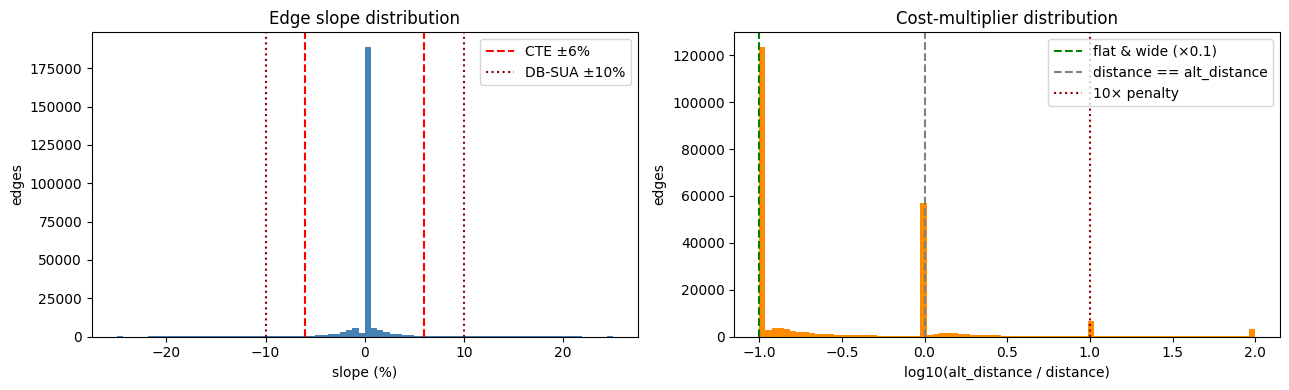

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

slopes_pct = edges_gdf["slope"].dropna() * 100
axs[0].hist(slopes_pct.clip(-25, 25), bins=80, color="steelblue")
axs[0].axvline( 6,  color="red",     linestyle="--", label="CTE \u00b16%")
axs[0].axvline(-6,  color="red",     linestyle="--")
axs[0].axvline( 10, color="darkred", linestyle=":",  label="DB-SUA \u00b110%")
axs[0].axvline(-10, color="darkred", linestyle=":")
axs[0].set_xlabel("slope (%)")
axs[0].set_ylabel("edges")
axs[0].set_title("Edge slope distribution")
axs[0].legend()

log_ratio = np.log10(edges_gdf["ratio"].clip(0.01, 100))
axs[1].hist(log_ratio, bins=80, color="darkorange")
axs[1].axvline(np.log10(0.1), color="green",   linestyle="--", label="flat & wide (\u00d70.1)")
axs[1].axvline(0,             color="grey",    linestyle="--", label="distance == alt_distance")
axs[1].axvline(1,             color="darkred", linestyle=":",  label="10\u00d7 penalty")
axs[1].set_xlabel("log10(alt_distance / distance)")
axs[1].set_ylabel("edges")
axs[1].set_title("Cost-multiplier distribution")
axs[1].legend()
plt.tight_layout()

## Routing comparison

Pick several origin/destination pairs in the same connected component and route them both ways. The primary route minimises raw `distance`; the alternate minimises `alt_distance`, so it should detour around steep or narrow segments.

Note: the tile2net source graph is heavily fragmented at kerb crossings, so candidate pairs are sampled only from components of at least 100 nodes.

In [6]:
# Build a node->component map so any pair we draw is guaranteed routable.
g = nx.from_pandas_edgelist(network.edges, source="from", target="to")
components = sorted(nx.connected_components(g), key=len, reverse=True)
print(f"{len(components):,} components; largest 5 sizes: {[len(c) for c in components[:5]]}")

candidate_comps = [list(c) for c in components if len(c) >= 100]
flat_candidates = np.array([n for c in candidate_comps for n in c])
comp_id = {n: i for i, c in enumerate(candidate_comps) for n in c}
print(f"Sampling pairs from {len(candidate_comps)} components ({len(flat_candidates):,} nodes total)")

def pick_diverging_pair(rng, attempts: int = 400):
    """Return (origin_xy, dest_xy, primary_gdf, alt_gdf) where the two routes differ."""
    for _ in range(attempts):
        n1, n2 = rng.choice(flat_candidates, size=2, replace=False)
        if comp_id[n1] != comp_id[n2]:
            continue
        o = (network.nodes.at[n1, "x"], network.nodes.at[n1, "y"])
        d = (network.nodes.at[n2, "x"], network.nodes.at[n2, "y"])
        p_ids = network.route(o, d, alternate=False)
        a_ids = network.route(o, d, alternate=True)
        if p_ids is None or a_ids is None or np.array_equal(p_ids, a_ids):
            continue
        return o, d, network.route_gdf(o, d, alternate=False), network.route_gdf(o, d, alternate=True)
    return None

rng = np.random.default_rng(seed=2026)
N_PAIRS = 4
pairs = []
while len(pairs) < N_PAIRS:
    found = pick_diverging_pair(rng)
    if found is None:
        print("Couldn't find another diverging pair within budget; stopping.")
        break
    pairs.append(found)
    _, _, p, a = found
    detour = (a["distance"].sum() / p["distance"].sum() - 1) * 100
    print(f"  pair {len(pairs)}: primary={p['distance'].sum():6.0f} m   alt={a['distance'].sum():6.0f} m   detour={detour:+5.1f}%")

1 components; largest 5 sizes: [79013]
Sampling pairs from 1 components (79,013 nodes total)
  pair 1: primary=  5483 m   alt=  5999 m   detour= +9.4%
  pair 2: primary=  9565 m   alt= 10822 m   detour=+13.1%
  pair 3: primary=  7659 m   alt=  7975 m   detour= +4.1%
  pair 4: primary=  4091 m   alt=  4767 m   detour=+16.5%


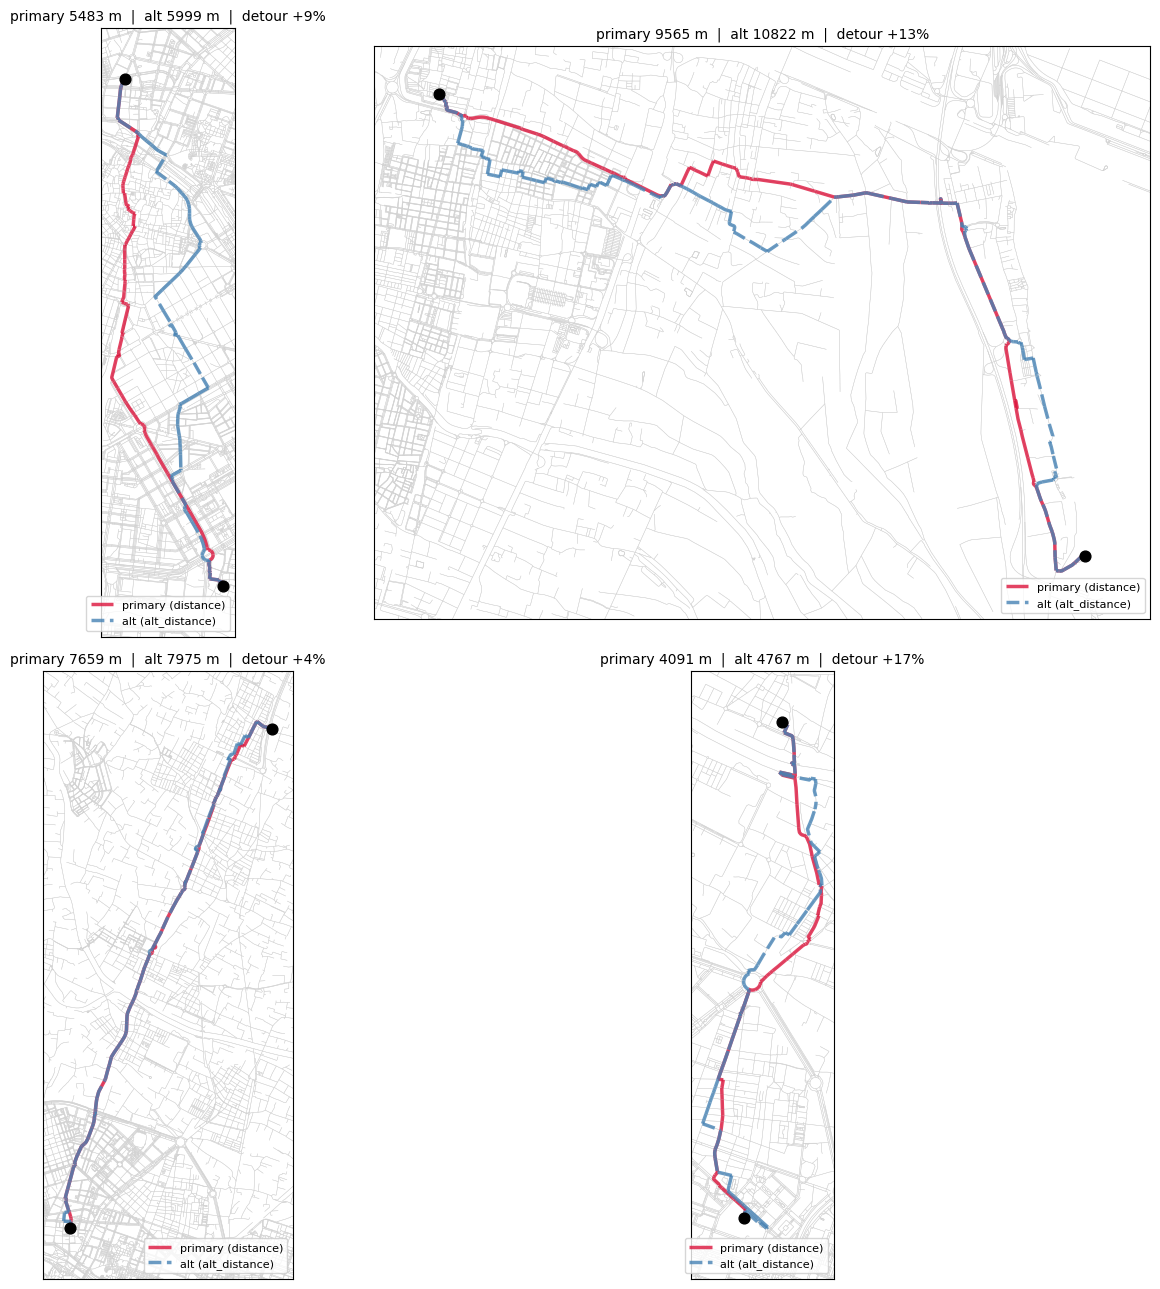

In [7]:
def local_backdrop(edges, bbox, pad=0.15):
    """Spatial slice of `edges` covering `bbox` (+ padding) so we don't redraw all 475k lines."""
    minx, miny, maxx, maxy = bbox
    mx, my = (maxx - minx) * pad, (maxy - miny) * pad
    return edges.cx[minx - mx:maxx + mx, miny - my:maxy + my]

rows = (len(pairs) + 1) // 2
fig, axs = plt.subplots(rows, 2, figsize=(14, 6.5 * rows))
axs = np.atleast_2d(axs).flatten()

for i, (o, d, primary, alt) in enumerate(pairs):
    ax = axs[i]
    b1, b2 = primary.total_bounds, alt.total_bounds
    bbox = (
        min(b1[0], b2[0]), min(b1[1], b2[1]),
        max(b1[2], b2[2]), max(b1[3], b2[3]),
    )
    local_backdrop(edges_gdf, bbox).plot(ax=ax, color="lightgrey", linewidth=0.3)
    primary.plot(ax=ax, color="crimson",   linewidth=2.5, alpha=0.8, label="primary (distance)")
    alt.plot(    ax=ax, color="steelblue", linewidth=2.5, alpha=0.8, linestyle="--", label="alt (alt_distance)")
    gpd.GeoDataFrame(
        {"k": ["O", "D"]}, geometry=[Point(*o), Point(*d)], crs=network.crs,
    ).plot(ax=ax, color="black", markersize=60, zorder=5)
    mx, my = (bbox[2] - bbox[0]) * 0.10, (bbox[3] - bbox[1]) * 0.10
    ax.set_xlim(bbox[0] - mx, bbox[2] + mx)
    ax.set_ylim(bbox[1] - my, bbox[3] + my)
    ax.set_aspect("equal")
    detour = (alt["distance"].sum() / primary["distance"].sum() - 1) * 100
    ax.set_title(
        f"primary {primary['distance'].sum():.0f} m  |  alt {alt['distance'].sum():.0f} m  |  detour {detour:+.0f}%",
        fontsize=10,
    )
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="lower right", fontsize=8)

for j in range(len(pairs), len(axs)):
    axs[j].set_visible(False)
plt.tight_layout()

### Summary table

Per-pair quantitative comparison: total distance, percent detour, the worst slope segment the route traverses, and the narrowest sidewalk segment.

In [8]:
summary = []
for i, (o, d, primary, alt) in enumerate(pairs, start=1):
    summary.append({
        "pair":              i,
        "primary_m":         primary["distance"].sum(),
        "alt_m":             alt["distance"].sum(),
        "detour_%":          (alt["distance"].sum() / primary["distance"].sum() - 1) * 100,
        "primary_max_|s|_%": primary["slope"].abs().max() * 100,
        "alt_max_|s|_%":     alt["slope"].abs().max() * 100,
        "primary_min_w_m":   primary["width"].min(),
        "alt_min_w_m":       alt["width"].min(),
    })
pd.DataFrame(summary).round(2)

,pair,primary_m,alt_m,detour_%,primary_max_|s|_%,alt_max_|s|_%,primary_min_w_m,alt_min_w_m
0,1,5482.54,5999.18,9.42,14.12,7.38,1.0,1.00
1,2,9565.46,10821.68,13.13,24.78,8.05,1.0,1.00
2,3,7659.28,7975.35,4.13,10.95,6.62,1.0,1.05
3,4,4091.09,4767.41,16.53,10.42,7.21,1.0,1.00


In [9]:
pairs[0]

((726550.22584, 4369304.840704),
 (725639.632903, 4374012.487261),
          from     to   distance  \
 60721   14138  14137  30.041573   
 60519   14137  14091  54.063714   
 60511   14091  14089   8.487466   
 60512   14089  14092  76.927890   
 60522   14092  49849   8.591593   
 ...       ...    ...        ...   
 23721    5411   5380   7.736436   
 23724    5380   6717  15.296414   
 29448    6717  39549  22.188852   
 154099  39549  39542   7.084003   
 154102  39542  67306  43.174608   
 
                                                  geometry     width  z_from  \
 60721   LINESTRING (726560.322 4369333.11, 726550.226 ...  1.000000     6.0   
 60519   LINESTRING (726560.322 4369333.11, 726515.165 ...  2.719009     6.0   
 60511   LINESTRING (726511.922 4369359.015, 726509.176...  3.924771     6.0   
 60512   LINESTRING (726435.407 4369368.69, 726503.762 ...  1.695130     6.0   
 60522   LINESTRING (726435.407 4369368.69, 726426.857 ...  2.907053     6.0   
 ...               

## Valencia open-data overlays

Two layers fetched in `scripts/initialize.py` from the Valencia geoportal and joined onto each edge by spatial proximity (both native EPSG:25830):

| column | source dataset | meaning |
|---|---|---|
| `kerb` / `kerb_type` | `cartografia-base-vorades-bordillos` | nearest *bordillo* within 4 m (`BORDILLO`, `BORDILLO JARDINERO`, `ACERA BORDILLO`) |
| `access_veh_a` | `vehiculos-movilidad-personal-tipo-a` | edge within 5 m of a type-A PMV lane |

These ride along in `edges_gdf` automatically (loaded via `network.edges`). If the cells below report the columns are missing, re-run `python -m scripts.initialize` with the `valencia:` block enabled in `config.yaml`.

In [10]:
overlay_cols = ["kerb", "kerb_type", "access_veh_a"]
HAS_OVERLAYS = all(c in edges_gdf.columns for c in overlay_cols)

if not HAS_OVERLAYS:
    missing = [c for c in overlay_cols if c not in edges_gdf.columns]
    print(f"Overlay columns missing: {missing}.")
    print("Re-run `python -m scripts.initialize` with the `valencia:` block in config.yaml.")
else:
    n = len(edges_gdf)
    for c in ["kerb", "access_veh_a"]:
        print(f"{c:<13} {int(edges_gdf[c].sum()):>7,}  ({edges_gdf[c].mean()*100:4.1f}% of {n:,} edges)")
    print("\nkerb_type:")
    print(edges_gdf["kerb_type"].value_counts(dropna=False).to_string())

kerb           88,552  (36.8% of 240,458 edges)
access_veh_a   73,840  (30.7% of 240,458 edges)

kerb_type:
kerb_type
NaN                   151906
ACERA BORDILLO         88245
BORDILLO                 297
BORDILLO JARDINERO        10


### Where are they?

Kerb edges coloured by `kerb_type`; the right-hand panel highlights the edges a type-A personal-mobility vehicle may use.

KeyboardInterrupt: 

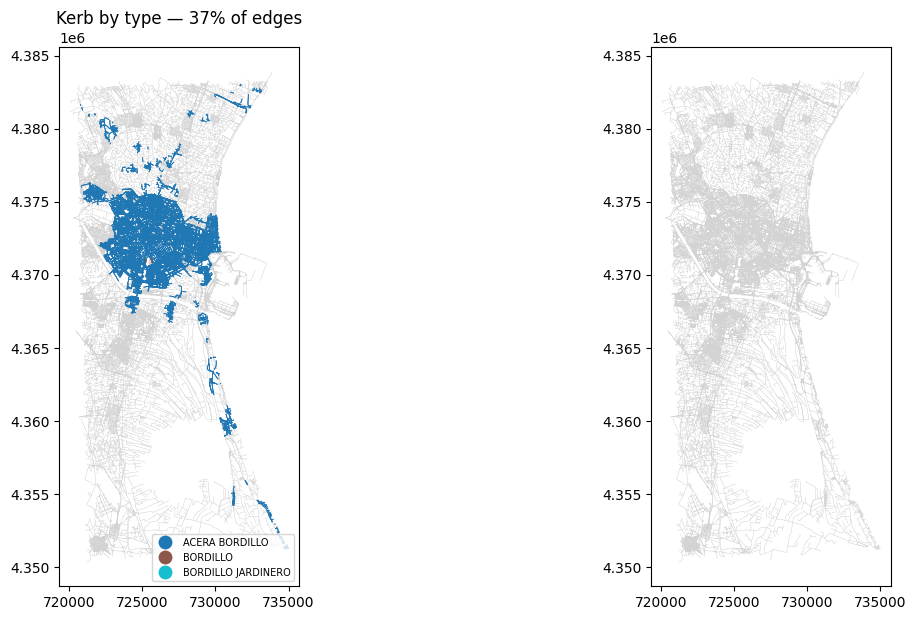

In [11]:
if HAS_OVERLAYS:
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))

    # 1) kerbs coloured by type
    edges_gdf.plot(ax=axs[0], color="lightgrey", linewidth=0.2)
    kt = edges_gdf[edges_gdf["kerb"]]
    if len(kt):
        kt.plot(
            ax=axs[0], column="kerb_type", categorical=True, linewidth=0.6,
            legend=True, legend_kwds={"loc": "lower right", "fontsize": 7},
        )
    axs[0].set_title(f"Kerb by type — {edges_gdf['kerb'].mean()*100:.0f}% of edges")

    # 2) type-A PMV-accessible edges
    edges_gdf.plot(ax=axs[1], color="lightgrey", linewidth=0.2)
    sel = edges_gdf[edges_gdf["access_veh_a"]]
    if len(sel):
        sel.plot(ax=axs[1], color="darkgreen", linewidth=0.6)
    axs[1].set_title(f"Type-A PMV accessible — {edges_gdf['access_veh_a'].mean()*100:.0f}% of edges")

    for ax in axs:
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
else:
    print("Skipped — overlay columns not present (see summary cell above).")

### How do the overlays relate to the slope / width model?

Do PMV-accessible edges line up with the flatter, wider sidewalks the `alt_distance` model already prefers, and where do kerbs fall relative to the width gate?

In [ ]:
if HAS_OVERLAYS:
    # Kerb presence vs the existing width-gate accessibility.
    wgate = edges_gdf["accesibility"].map({0: "w<1.50 m", 1: "w≥1.50 m"})
    print("Kerb presence vs width gate (edge counts):")
    print(pd.crosstab(wgate, edges_gdf["kerb"], colnames=["has kerb"]))

    # Slope / width profile of type-A PMV-accessible edges vs the rest.
    print("\nMedian |slope| (%) and median width (m) by type-A PMV access:")
    grp = edges_gdf.groupby("access_veh_a")
    summary_access = pd.DataFrame({
        "median |slope| %": grp["abs_slope"].median() * 100,
        "median width m":   grp["width"].median(),
        "edges":            grp.size(),
    })
    display(summary_access.round(2))
else:
    print("Skipped — overlay columns not present (see summary cell above).")

Kerb presence vs width gate (edge counts):
has kerb       False  True 
accesibility               
w<1.50 m       38242  16954
w≥1.50 m      113664  71598

Median |slope| (%) and median width (m) by type-A PMV access:


,median |slope| %,median width m,edges
access_veh_a,,,
False,0.0,2.4,166618
True,0.0,2.8,73840


## Crossing-based kerb penalty (Option 5)

`alt_distance` now folds in a multiplicative kerb factor

$$M_{\text{kerb}} = \exp\!\bigl(k_\kappa \cdot \min(\texttt{kerb\_cross},\,c)\bigr), \qquad k_\kappa = \ln 10,\ c = 2,$$

where `kerb_cross` is the number of kerb lines an edge **crosses** (a curb the route must mount), counted in `compute_valencia_features` via a `crosses` spatial join. Each crossing multiplies the edge cost by 10; a two-kerb street crossing costs ×100. Parallel kerbs — the normal sidewalk boundary — score 0 and are untouched.

`kerb_cross` is **clamped at `kerb_cross_cap = 2`**: a real crossing traverses at most two curbs (one per side), so higher raw counts are artifacts of the fragmented kerb layer (median ~7 m segments) where a long or skewed edge skims many pieces. Uncapped, those edges reached ×10¹⁶, giving `alt_distance` a ~20-order-of-magnitude range that made pandana's contraction-hierarchy build (the first cell) pathologically slow.

In [ ]:
HAS_KERB_CROSS = "kerb_cross" in edges_gdf.columns
if not HAS_KERB_CROSS:
    print("`kerb_cross` not present — re-run `python -m scripts.initialize` "
          "with the `valencia:` block, then reload this notebook.")
else:
    K_KERB = np.log(10)   # config default; each crossing → ×10
    KERB_CROSS_CAP = 2    # config default; must match alt_distance computation
    edges_gdf["kerb_cross"] = edges_gdf["kerb_cross"].fillna(0).astype(int)
    # Cap mirrors compute_accesibility_distance: a real crossing traverses ≤2
    # curbs; higher counts are fragmented-kerb-layer artifacts.
    edges_gdf["M_kerb"] = np.exp(K_KERB * edges_gdf["kerb_cross"].clip(upper=KERB_CROSS_CAP))

    print("kerb_cross distribution (raw counts):")
    print(edges_gdf["kerb_cross"].value_counts().sort_index().to_string())

    pen = edges_gdf["kerb_cross"] > 0
    n = len(edges_gdf)
    print(f"\n{pen.sum():,} edges cross ≥1 kerb ({pen.mean()*100:.1f}% of {n:,}); "
          f"penalty capped at ×{np.exp(K_KERB*KERB_CROSS_CAP):.0f} (kerb_cross_cap={KERB_CROSS_CAP})")
    print(f"M_kerb among penalised: median ×{edges_gdf.loc[pen,'M_kerb'].median():.0f}, "
          f"max ×{edges_gdf['M_kerb'].max():.0f}")

    # Share of total alt_distance mass contributed by the (capped) kerb factor.
    pre = (edges_gdf["alt_distance"] / edges_gdf["M_kerb"]).sum()
    share = 1 - pre / edges_gdf["alt_distance"].sum()
    print(f"Kerb factor accounts for {share*100:.1f}% of summed alt_distance")

kerb_cross distribution (raw counts):
kerb_cross
0     209556
1      26940
2       3260
3        432
4        182
5         38
6         18
7         18
9          4
10         4
11         2
12         2
16         2

30,902 edges cross ≥1 kerb (12.9% of 240,458); penalty capped at ×100 (kerb_cross_cap=2)
M_kerb among penalised: median ×10, max ×100
Kerb factor accounts for 51.2% of summed alt_distance


### Where the crossings are

Edges coloured by `kerb_cross`: the parallel-boundary edges (0) form the grey backdrop, curb crossings light up. They should cluster at street crossings / connectors, not run along sidewalks — that's the check that we're penalising traversal, not mere kerb presence.

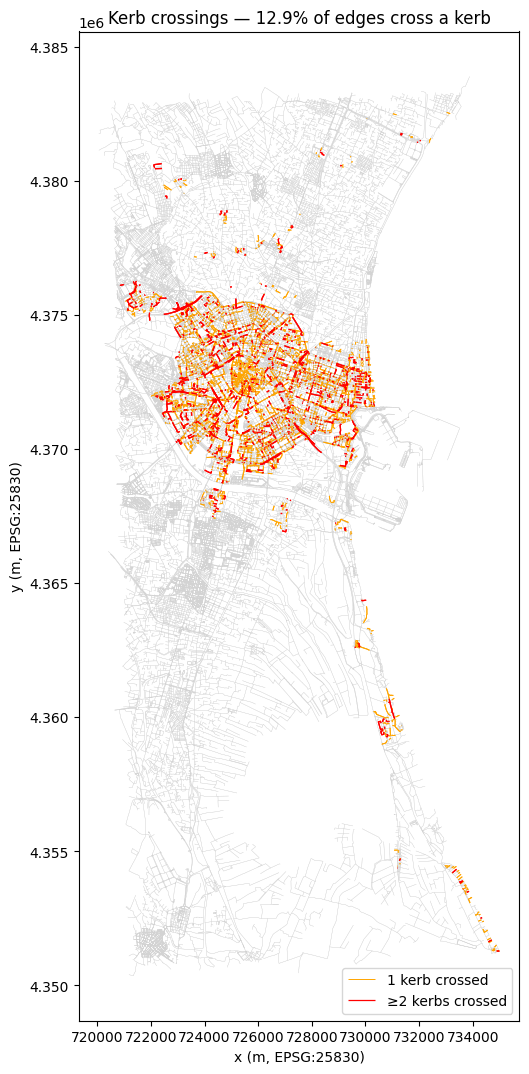

In [ ]:
if HAS_KERB_CROSS:
    fig, ax = plt.subplots(figsize=(11, 11))
    edges_gdf[edges_gdf["kerb_cross"] == 0].plot(ax=ax, color="lightgrey", linewidth=0.2)
    edges_gdf[edges_gdf["kerb_cross"] == 1].plot(
        ax=ax, color="orange", linewidth=0.7, label="1 kerb crossed")
    edges_gdf[edges_gdf["kerb_cross"] >= 2].plot(
        ax=ax, color="red", linewidth=0.9, label="≥2 kerbs crossed")
    ax.set_aspect("equal")
    ax.set_title(f"Kerb crossings — {(edges_gdf['kerb_cross']>0).mean()*100:.1f}% of edges cross a kerb")
    ax.set_xlabel("x (m, EPSG:25830)"); ax.set_ylabel("y (m, EPSG:25830)")
    ax.legend(loc="lower right")
    plt.tight_layout()
else:
    print("Skipped — kerb_cross not present.")

### Effect on routing

For the origin/destination pairs sampled in the routing section above, count how many kerb crossings the distance-optimal (`primary`) route traverses versus the accessibility-optimal (`alt`) route. With the penalty active, `alt` should mount fewer curbs (or pay for them only when unavoidable).

In [ ]:
if HAS_KERB_CROSS and "pairs" in dir() and pairs:
    # For the O/D pairs sampled in the routing section, count kerb crossings on
    # the distance-optimal (primary) route vs the accessibility-optimal (alt) one.
    rows = []
    for i, (o, d, primary, alt) in enumerate(pairs, start=1):
        rows.append({
            "pair":          i,
            "primary_kerbs": int(primary["kerb_cross"].fillna(0).sum()),
            "alt_kerbs":     int(alt["kerb_cross"].fillna(0).sum()),
            "primary_m":     round(primary["distance"].sum()),
            "alt_m":         round(alt["distance"].sum()),
        })
    display(pd.DataFrame(rows))
else:
    print("Run the routing-comparison section above first (defines `pairs`), "
          "with a kerb_cross-enabled DB.")

,pair,primary_kerbs,alt_kerbs,primary_m,alt_m
0,1,38,1,5483,5999
1,2,5,1,9565,10822
2,3,4,0,7659,7975
3,4,1,1,4091,4767


## Type-A PMV routing (`veh_a_distance`)

A second weighted metric for type-A personal-mobility vehicles. It is **the same cost as `alt_distance` with the pedestrian width gate replaced by the lane-permission gate**:

$$\texttt{veh\_a\_distance} = \texttt{distance}\cdot \exp(k_{\uparrow}s_+ + k_{\downarrow}s_-)\cdot M_{\text{kerb}} \,\big/\, 10^{\texttt{access\_veh\_a}}$$

So an edge on a type-A lane (`access_veh_a = 1`) is 10× cheaper; off-lane edges pay full. Slope and kerb terms (and their caps) are inherited unchanged. The router exposes it as `mode="veh_a"`, and the API adds a `ruta_veh_a` route.

In [ ]:
HAS_VEH_A = "veh_a_distance" in edges_gdf.columns
if not HAS_VEH_A:
    print("`veh_a_distance` not present — re-run `python -m scripts.initialize`, then reload.")
else:
    edges_gdf["veh_a_ratio"] = edges_gdf["veh_a_distance"] / edges_gdf["distance"]
    on = edges_gdf["access_veh_a"].fillna(False)
    print(f"on a type-A lane: {on.sum():,} edges ({on.mean()*100:.1f}%)")
    print("veh_a_distance / distance (median):")
    print(f"  on-lane  {edges_gdf.loc[on, 'veh_a_ratio'].median():.3f}")
    print(f"  off-lane {edges_gdf.loc[~on, 'veh_a_ratio'].median():.3f}   "
          f"(off ÷ on ≈ {edges_gdf.loc[~on,'veh_a_ratio'].median()/edges_gdf.loc[on,'veh_a_ratio'].median():.0f}× — the lane gate)")
    print(f"\nfor reference, alt_distance/distance median = "
          f"{(edges_gdf['alt_distance']/edges_gdf['distance']).median():.3f} "
          f"(wheelchair metric, width gate instead of the lane gate)")

on a type-A lane: 73,840 edges (30.7%)
veh_a_distance / distance (median):
  on-lane  0.100
  off-lane 1.000   (off ÷ on ≈ 10× — the lane gate)

for reference, alt_distance/distance median = 0.100 (wheelchair metric, width gate instead of the lane gate)


### Type-A vs wheelchair routing

For the O/D pairs sampled earlier, route on the type-A network (`mode="veh_a"`) and compare against the accessibility route (`alt`): total length and the share of each route that runs on a type-A lane. The type-A route should spend more of its length on-lane, trading some distance for it.

In [ ]:
if HAS_VEH_A and "pairs" in dir() and pairs:
    def on_lane_m(g):
        return float(g.loc[g["access_veh_a"] == True, "distance"].sum()) if g is not None else 0.0

    rows = []
    for i, (o, d, primary, alt) in enumerate(pairs, start=1):
        veh = network.route_gdf(o, d, mode="veh_a")
        rows.append({
            "pair":            i,
            "alt_m":           round(alt["distance"].sum()),
            "veh_a_m":         round(veh["distance"].sum()) if veh is not None else None,
            "alt_on_lane_%":   round(on_lane_m(alt) / alt["distance"].sum() * 100),
            "veh_a_on_lane_%": round(on_lane_m(veh) / veh["distance"].sum() * 100) if veh is not None else None,
        })
    display(pd.DataFrame(rows))
else:
    print("Need `pairs` (run the routing section) and a veh_a-enabled DB.")

,pair,alt_m,veh_a_m,alt_on_lane_%,veh_a_on_lane_%
0,1,5999,6787,86,100
1,2,10822,10765,52,96
2,3,7975,10333,49,69
3,4,4767,5377,44,69


In [13]:
pairs[0]

((726550.22584, 4369304.840704),
 (725639.632903, 4374012.487261),
          from     to   distance  \
 60721   14138  14137  30.041573   
 60519   14137  14091  54.063714   
 60511   14091  14089   8.487466   
 60512   14089  14092  76.927890   
 60522   14092  49849   8.591593   
 ...       ...    ...        ...   
 23721    5411   5380   7.736436   
 23724    5380   6717  15.296414   
 29448    6717  39549  22.188852   
 154099  39549  39542   7.084003   
 154102  39542  67306  43.174608   
 
                                                  geometry     width  z_from  \
 60721   LINESTRING (726560.322 4369333.11, 726550.226 ...  1.000000     6.0   
 60519   LINESTRING (726560.322 4369333.11, 726515.165 ...  2.719009     6.0   
 60511   LINESTRING (726511.922 4369359.015, 726509.176...  3.924771     6.0   
 60512   LINESTRING (726435.407 4369368.69, 726503.762 ...  1.695130     6.0   
 60522   LINESTRING (726435.407 4369368.69, 726426.857 ...  2.907053     6.0   
 ...               